In [40]:
# import required modules 
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [41]:
# change working directory
os.chdir(r"/Users/f/downloads")

# define data csv to be read
df = pd.read_csv('AB_NYC_2019_cleaned.csv')

# preview dataset
df.head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_review,log_price,availability_ratio,is_multi_host,has_reviews
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438,5.010635,1.000000,1,1
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224,5.420535,0.972603,1,1
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,226,5.017280,1.000000,0,0
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179,4.499810,0.531507,0,1
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407,4.394449,0.000000,0,1


In [42]:
# Define Target
y = df['log_price']

# Remove identifiers, target leakage
X = df.drop([
    'id',
    'host_id',
    'price',      # avoid leakage
    'log_price'   # target
], axis=1)

In [43]:
# Because we only have 5 neighbourhood groups we use One-Hot Encoding

X = pd.get_dummies(X, columns=['neighbourhood_group'], drop_first=False)
X = pd.get_dummies(X, columns=['room_type'], drop_first=False)

In [44]:
# Create mapping from neighbourhood to median log_price
# granular neighbourhood-level location was target encoded using median log price to capture local pricing dynamics without creating high-dimensional sparsity
neighbourhood_median = df.groupby('neighbourhood')['log_price'].median()

# Map values
X['neighbourhood_encoded'] = df['neighbourhood'].map(neighbourhood_median)

# Drop original column
X = X.drop('neighbourhood', axis=1)

In [45]:
# Train-test split
# test size is 20% of the sample (standard for linear regression modelling)
# A fixed random seed (random_state=42) was used to ensure reproducibility of the train-test split and clustering results
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [46]:
# Train the linear regression model 

from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# Evaluate the model 

from sklearn.metrics import r2_score, mean_squared_error

y_pred = regr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE (log scale):", rmse)

R² Score: 0.5300533551064877
RMSE (log scale): 0.4750624179096847


In [48]:
#Train the final model 
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
# Create Prediction Function

def predict_price(model, input_data, X_columns, neigh_median):

    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])

    # Target encode neighbourhood
    input_df['neighbourhood_encoded'] = input_df['neighbourhood'].map(neigh_median)

    # Drop original neighbourhood
    input_df = input_df.drop('neighbourhood', axis=1)

    # One-hot encode borough & room_type
    input_df = pd.get_dummies(input_df)

    # Align columns with training data
    input_df = input_df.reindex(columns=X_columns, fill_value=0)

    # Predict log price
    predicted_log_price = model.predict(input_df)

    # Convert back to real price
    predicted_price = np.expm1(predicted_log_price)

    return predicted_price[0]

In [50]:
# Example Input


new_listing = {
    'latitude': 40.75,
    'longitude': -73.98,
    'minimum_nights': 2,
    'number_of_reviews': 50,
    'reviews_per_month': 1.5,
    'calculated_host_listings_count': 1,
    'availability_ratio': 0.30,
    'days_since_review': 3,
    'is_multi_host': 0,
    'has_review': 1,
    'neighbourhood_group': 'Manhattan',
    'neighbourhood': 'Midtown',
    'room_type': 'Entire home/apt'
}

In [51]:
# Using the regression model built we get a preditction using the new listing input 
# X columns is using the column ordered defined previous step
# neigh median transforms input neighbourhood into log median price needed since we target encoded

predicted = predict_price(regr, new_listing, X.columns, neighbourhood_median)

print("Predicted Price: $", round(predicted, 2))

Predicted Price: $ 255.8


In [52]:
# Clustering - K Means Clustering 


In [53]:
#  Select Features for Segmentation
# clustering should reveal behavioural & pricing patterns - Location can later be analysed across clusters

cluster_features = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_ratio',
    'calculated_host_listings_count',
    'days_since_review',
    'is_multi_host'
]

cluster_df = df[cluster_features].copy()

In [54]:
# Scale Features - K means clustering uses euclidean distance


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

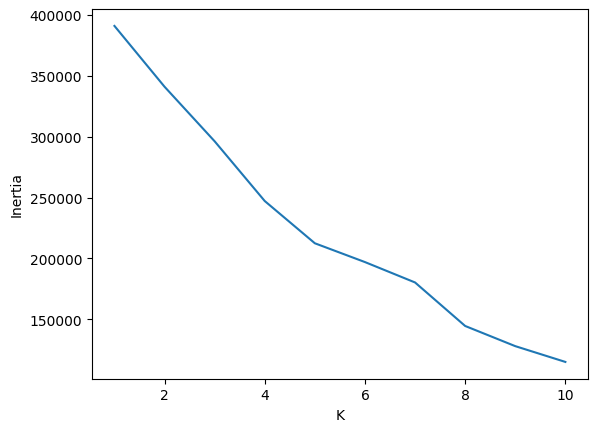

In [55]:
# Using the elbow method, find the optimal K 

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [56]:
# Taking K = 4 from the above chart

kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_data)

In [57]:

cluster_summary = df.groupby('cluster')[cluster_features].mean()
print(cluster_summary)

              price  minimum_nights  number_of_reviews  reviews_per_month  \
cluster                                                                     
0        132.190703        4.837110           6.256116           0.147360   
1        153.936186        6.736296           9.888430           0.628506   
2        399.331197       49.758547           2.611111           0.367607   
3        127.115031        2.650425          89.487129           3.696958   

         availability_ratio  calculated_host_listings_count  \
cluster                                                       
0                  0.063263                        1.458280   
1                  0.304927                        3.022765   
2                  0.748732                      159.747151   
3                  0.471790                        2.287520   

         days_since_review  is_multi_host  
cluster                                    
0              1174.646665       0.115503  
1               275.614472

In [58]:
# Clustering revealed four distinct segments differentiated by pricing strategy, host professionalism, demand intensity, and listing availability. 
# The strongest performing segment was identified as low-priced, high-review velocity listings, 
# while the highest-priced listings were dominated by professional multi-property hosts.

In [59]:
# using business logic map define business segments and map to numbers

# Create mapping dictionary
cluster_labels = {
    0: "Dormant Listings",
    1: "Standard Listings",
    2: "Professional / Investment Listings",
    3: "High-Demand Value Listings"
}

# Map cluster numbers to readable segment names
df['segment'] = df['cluster'].map(cluster_labels)

# Check results
print(df[['cluster', 'segment']].head())

   cluster                     segment
0        1           Standard Listings
1        1           Standard Listings
2        1           Standard Listings
3        3  High-Demand Value Listings
4        1           Standard Listings


In [60]:
# Create prediction function for new listings 

def predict_segment(kmeans_model, scaler, input_data, feature_columns, label_mapping):

    # Convert dictionary input into DataFrame
    input_df = pd.DataFrame([input_data])

    # Ensure correct column order
    input_df = input_df[feature_columns]

    # Scale input using SAME scaler used for training
    scaled_input = scaler.transform(input_df)

    # Predict cluster
    cluster_number = kmeans_model.predict(scaled_input)[0]

    # Convert cluster number to business label
    return label_mapping[cluster_number]

# Predict segment for new listing 

new_listing = {
    'price': 250,
    'minimum_nights': 3,
    'number_of_reviews': 45,
    'reviews_per_month': 5,
    'availability_ratio': 0.30,
    'calculated_host_listings_count': 1,
    'days_since_review': 50,
    'is_multi_host': 0
}

segment_prediction = predict_segment(
    kmeans_model=kmeans,
    scaler=scaler,
    input_data=new_listing,
    feature_columns=cluster_features,
    label_mapping=cluster_labels
)

print("Predicted Segment:", segment_prediction)

In [61]:
# show segement split in dataset
print(df['segment'].value_counts())

segment
Standard Listings                     31012
High-Demand Value Listings             8702
Dormant Listings                       7766
Professional / Investment Listings     1404
Name: count, dtype: int64


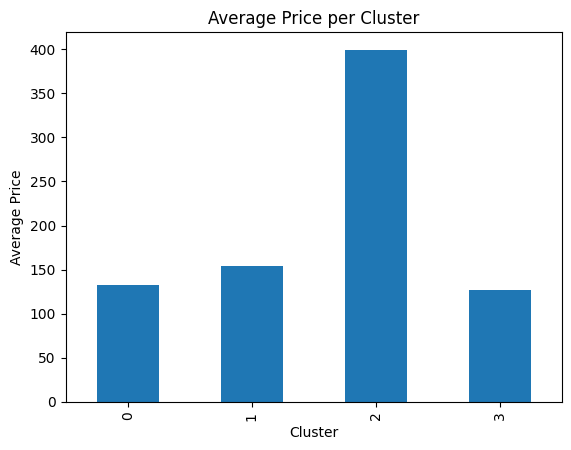

In [62]:
# Fit KMeans (using 4 clusters as before)
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Calculate average price per cluster
cluster_price = df.groupby('cluster')['price'].mean()

# Plot chart
plt.figure()
cluster_price.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Average Price")
plt.title("Average Price per Cluster")

plt.show()


In [65]:
# Import libraries for DBScan
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X_scaled = scaler.fit_transform(X)
dbscan = DBSCAN(eps=0.8, min_samples=10)
df['db_cluster'] = dbscan.fit_predict(X_scaled)

In [76]:
dbscan = DBSCAN(eps=2.4, min_samples=10) # min_samples is the minimum required to form clusters & eps is neighbourhood radius
df['db_cluster'] = dbscan.fit_predict(X_scaled)

In [77]:
print(df['db_cluster'].value_counts())

db_cluster
 1     9701
 3     8130
 0     7968
 4     6267
 5     2885
 7     2630
 6     2127
 8     1712
 2     1658
 12    1380
 17     686
 9      518
-1      415
 13     348
 18     347
 11     296
 19     282
 27     200
 30     199
 15     153
 22     142
 16     138
 10     126
 20     123
 29     120
 14     119
 23      69
 21      43
 26      39
 28      28
 24      12
 25      12
 31      11
Name: count, dtype: int64


In [78]:
noise_count = sum(df['db_cluster'] == -1)
print("Number of noise points:", noise_count)

Number of noise points: 415


In [79]:
# Remove noise for silhouette calculation
mask = df['db_cluster'] != -1

if len(df['db_cluster'].unique()) > 2:
    score = silhouette_score(X_scaled[mask], df.loc[mask, 'db_cluster'])
    print("Silhouette Score:", score)

Silhouette Score: 0.19873974694509464


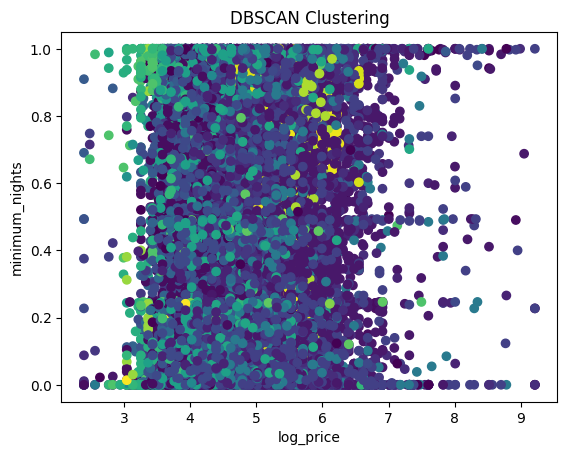

In [80]:
plt.figure()
plt.scatter(df['log_price'], df['availability_ratio'], 
            c=df['db_cluster'])

plt.xlabel("log_price")
plt.ylabel("minimum_nights")
plt.title("DBSCAN Clustering")
plt.show()

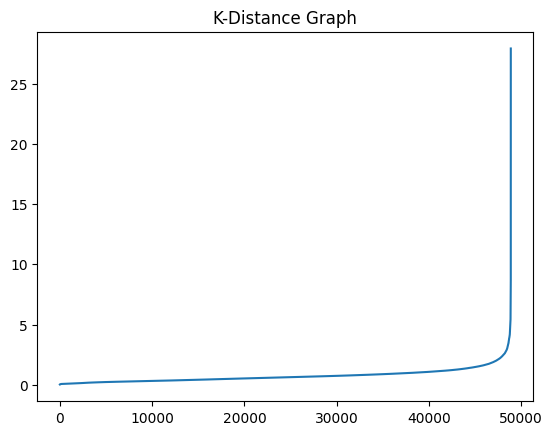

In [75]:
# tune eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,9])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.show()